In [8]:
# Use DeepSurv from the repo
import sys
sys.path.append('/Users/xiaokangzhang/tools/DeepSurv/deepsurv')
import deepsurv

from deepsurv_logger import DeepSurvLogger, TensorboardLogger
import utils
import viz

import numpy as np
import pandas as pd

import lasagne
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split

In [10]:
train_dataset_fp = '../data/time_epic_bcr_tcga.csv'
train_df = pd.read_csv(train_dataset_fp, index_col = 0)
train_df.head()

,B cell,Cancer associated fibroblast,T cell CD4+,T cell CD8+,Endothelial cell,Macrophage,NK cell,uncharacterized cell,bcr_days,biochemical_recurrence
TCGA.2A.A8VL,0.006845,0.012113,0.135687,0.050132,0.056108,0.000755,1.101543e-09,0.738360,621,NO
TCGA.2A.A8VO,0.004813,0.028238,0.104363,0.041729,0.059345,0.001986,4.199180e-08,0.759526,1332,NO
TCGA.2A.A8VT,0.004278,0.028293,0.126963,0.076329,0.073931,0.002092,5.518708e-10,0.688115,995,NO
TCGA.2A.A8VV,0.005032,0.021033,0.098295,0.046204,0.087229,0.000346,3.361014e-09,0.741860,671,NO
TCGA.2A.A8VX,0.019723,0.031772,0.071104,0.032423,0.015731,0.000563,6.703885e-10,0.828684,1033,NO


In [11]:
train_df, valid_df = train_test_split(train_df, test_size = 0.2, random_state=99, shuffle=True)

In [12]:
train_df.shape

(324, 10)

In [13]:
# remove all-zero columns
train_df = train_df.loc[:, (train_df != 0).any(axis = 0)]
train_df.shape

(324, 10)

In [14]:
# event_col is the header in the df that represents the 'Event / Status' indicator
# time_col is the header in the df that represents the event time
def dataframe_to_deepsurv_ds(df, event_col = 'biochemical_recurrence', time_col = 'bcr_days', event_symbol = "YES"):
    # Extract the event and time columns as numpy arrays
    e = (1 * (df[event_col].values.astype(np.str_) == event_symbol)).astype(np.int32)
    t = df[time_col].values.astype(np.float32)

    # Extract the patient's covariates as a numpy array
    x_df = df.drop([event_col, time_col], axis = 1)
    x = x_df.values.astype(np.float32)
    
    # Return the deep surv dataframe
    return {
        'x' : x,
        'e' : e,
        't' : t
    }

In [15]:
# If the headers of the csv change, you can replace the values of 
# 'event_col' and 'time_col' with the names of the new headers
# You can also use this function on your training dataset, validation dataset, and testing dataset
train_data = dataframe_to_deepsurv_ds(train_df, event_col = 'biochemical_recurrence', time_col= 'bcr_days', event_symbol = "YES")
valid_data = dataframe_to_deepsurv_ds(valid_df, event_col = 'biochemical_recurrence', time_col= 'bcr_days', event_symbol = "YES")

In [16]:
test_dataset_fp = '../data/time_epic_bcr_mskcc.csv'
test_df = pd.read_csv(test_dataset_fp, index_col = 0)
test_df.head()

,B cell,Cancer associated fibroblast,T cell CD4+,T cell CD8+,Endothelial cell,Macrophage,NK cell,uncharacterized cell,BCR_FreeTime,BCR_Event
PCA0001,0.036842,0.007083,0.131724,0.102217,0.100008,0.005386,1.793152e-09,0.616740,18.49731,BCR_Algorithm
PCA0002,0.033182,0.007025,0.143259,0.100806,0.098667,0.005778,8.832583e-10,0.611283,58.02177,NO
PCA0003,0.034283,0.007087,0.139498,0.101518,0.094201,0.005565,3.285272e-10,0.617847,93.14367,NO
PCA0005,0.031431,0.006660,0.140682,0.099561,0.096653,0.005333,4.423661e-10,0.619679,126.09710,NO
PCA0007,0.031993,0.006677,0.136424,0.099629,0.096805,0.005331,1.085342e-09,0.623142,98.59759,NO


In [17]:
test_df.shape

(140, 10)

In [18]:
test_data = dataframe_to_deepsurv_ds(test_df, event_col = 'BCR_Event', time_col= 'BCR_FreeTime', event_symbol = "BCR_Algorithm")

In [19]:
hyperparams = {
    'L2_reg': 10.0,
    'batch_norm': True,
    'dropout': 0.4,
    'hidden_layers_sizes': [25, 25],
    'learning_rate': 1e-05,
    'lr_decay': 0.001,
    'momentum': 0.9,
    'n_in': train_data['x'].shape[1],
    'standardize': False
}

In [20]:
# Create an instance of DeepSurv using the hyperparams defined above
model = deepsurv.DeepSurv(**hyperparams)

# DeepSurv can now leverage TensorBoard to monitor training and validation
# This section of code is optional. If you don't want to use the tensorboard logger
# Uncomment the below line, and comment out the other three lines: 
# logger = None

In [21]:
experiment_name = 'test_tcga'
logdir = './logs/tensorboard/'
logger = TensorboardLogger(experiment_name, logdir=logdir)

In [22]:
# Now we train the model
update_fn=lasagne.updates.nesterov_momentum # The type of optimizer to use. \
                                            # Check out http://lasagne.readthedocs.io/en/latest/modules/updates.html \
                                            # for other optimizers to use

In [23]:
n_epochs = 2000

# If you have validation data, you can add it as the second parameter to the function
metrics = model.train(train_data, valid_data, n_epochs=n_epochs, logger=logger, update_fn=update_fn)

2022-01-24 11:31:11,658 - Training step 0/2000    |                         | - loss: 20.8423 - ci: 0.4949
2022-01-24 11:31:28,156 - Training step 250/2000  |***                      | - loss: 10.7029 - ci: 0.4468
2022-01-24 11:31:44,713 - Training step 500/2000  |******                   | - loss: 7.1130 - ci: 0.5289
2022-01-24 11:32:01,181 - Training step 750/2000  |*********                | - loss: 5.7865 - ci: 0.5906
2022-01-24 11:32:17,873 - Training step 1000/2000 |************             | - loss: 5.3846 - ci: 0.6703
2022-01-24 11:32:34,509 - Training step 1250/2000 |***************          | - loss: 5.1703 - ci: 0.6832
2022-01-24 11:32:51,159 - Training step 1500/2000 |******************       | - loss: 5.1106 - ci: 0.6848
2022-01-24 11:33:07,703 - Training step 1750/2000 |*********************    | - loss: 5.1009 - ci: 0.6880
2022-01-24 11:33:24,196 - Finished Training with 2000 iterations in 133.48s


Train C-Index: (1999, 0.6903460837887068)
Valid C-Index:  (1750, 0.5856873822975518)


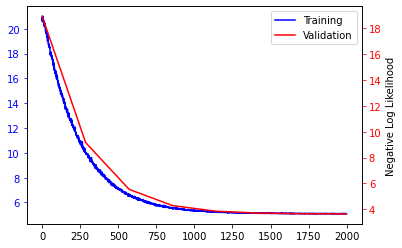

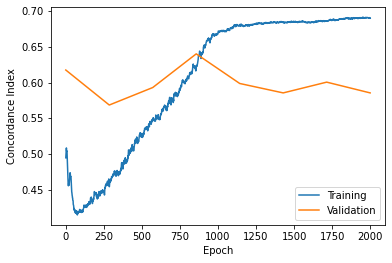

In [24]:
# Print the final metrics
print('Train C-Index:', metrics['c-index'][-1])
print('Valid C-Index: ',metrics['valid_c-index'][-1])

# Plot the training / validation curves
viz.plot_log(metrics)

In [25]:
pred = model.predict_risk(test_data['x'])

In [26]:
import pysurvival

In [27]:
from lifelines.utils import concordance_index as ci_lifelines

In [28]:
ci_lifelines(test_data['t'], -pred, test_data['e'])

0.6236763508009775

In [29]:
from pysurvival.utils.metrics import concordance_index as ci_pysurvival

In [30]:
ci_pysurvival(model, train_data['x'], train_data['t'], train_data['e'])

0.6851861463906257

In [31]:
model.get_concordance_index(train_data['x'], train_data['t'], train_data['e'])

0.6903460837887068

In [32]:
ci_pysurvival(model, test_data['x'], test_data['t'], test_data['e'])

0.5516508928848431

In [33]:
model.get_concordance_index(test_data['x'], test_data['t'], test_data['e'])

0.6236763508009775

In [34]:
# save the prediction of MSKCC to file
rs_dict = {"patient": test_df.index.values, "risk.score": pred[:, 0]}

In [35]:
rs_df = pd.DataFrame.from_dict(rs_dict)

In [36]:
rs_df.head()

,patient,risk.score
0,PCA0001,0.036719
1,PCA0002,0.035403
2,PCA0003,0.031720
3,PCA0005,0.030846
4,PCA0007,0.030109


In [37]:
rs_df.to_csv("../data/risk_score_from_DeepSurv_mskcc.csv", index = False)